# Final Project: N-BEATS

In [1]:
import warnings
import logging

warnings.filterwarnings("ignore")
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("lightning").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning.utilities.rank_zero").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning.accelerators.cuda").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning.callbacks.model_summary").setLevel(logging.ERROR)
logging.getLogger("lightning_fabric").setLevel(logging.ERROR)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 0 Load Data

In [ ]:
df_raw = pd.read_parquet("../../data/processed/merged_features_weekly.parquet")

commodities = [
    "Beetroot",
    "Bulb Onions (Yellow)",
    "Cabbage",
    "Carrots",
    "Cucumbers",
    "Curly kale",
    "Lettuce",
    "Tomatoes (Round)",
]

df = df_raw[df_raw["commodity"].isin(commodities)].copy()
df = df.sort_values(["commodity", "date"]).reset_index(drop=True)

train_df = df[df["split"] == "train"].copy()
test_df = df[df["split"] == "test"].copy()

print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")
print(f"Commodities: {train_df['commodity'].nunique()}")

Train: 3159 rows | Test: 207 rows
Commodities: 8


In [4]:
nf_train = train_df[["commodity", "date", "target_price"]].copy()
nf_train.columns = ["unique_id", "ds", "y"]
nf_train["y"] = nf_train["y"].astype(float)

nf_test = test_df[["commodity", "date", "target_price"]].copy()
nf_test.columns = ["unique_id", "ds", "y"]
nf_test["y"] = nf_test["y"].astype(float)

nf_full = pd.concat([nf_train, nf_test]).sort_values(["unique_id", "ds"]).reset_index(drop=True)

max_h = nf_test.groupby("unique_id").size().max()
print(f"Max forecast horizon: {max_h} weeks")

Max forecast horizon: 28 weeks


## 1 Train N-BEATS

In [5]:
from neuralforecast.core import NeuralForecast
from neuralforecast.models import NBEATS

horizon = max_h

nbeats = NBEATS(
    h=horizon,
    input_size=2 * horizon,
    max_steps=1000,
    early_stop_patience_steps=5,
)

nf = NeuralForecast(models=[nbeats], freq="W")

start_time = time.time()
nf.fit(df=nf_train, val_size=horizon)
train_elapsed = time.time() - start_time
print(f"Training completed in {train_elapsed:.1f}s")

Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4070 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Training completed in 14.9s


## 2 Forecast

In [6]:
start_time = time.time()
nbeats_forecasts = nf.predict(df=nf_train)
forecast_elapsed = time.time() - start_time
print(f"Forecast completed in {forecast_elapsed:.1f}s")

nbeats_forecasts = nbeats_forecasts.reset_index()
nbeats_forecasts.head()

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Forecast completed in 0.2s


,index,unique_id,ds,NBEATS
0,0,Beetroot,2024-12-22,0.655380
1,1,Beetroot,2024-12-29,0.648755
2,2,Beetroot,2025-01-05,0.672244
3,3,Beetroot,2025-01-12,0.668567
4,4,Beetroot,2025-01-19,0.630077


## 3 Evaluation

In [7]:
forecast_sorted = nbeats_forecasts.sort_values(["unique_id", "ds"]).copy()
test_sorted = nf_test.sort_values(["unique_id", "ds"]).copy()

forecast_sorted["_rank"] = forecast_sorted.groupby("unique_id").cumcount()
test_sorted["_rank"] = test_sorted.groupby("unique_id").cumcount()

eval_df = test_sorted.merge(
    forecast_sorted[["unique_id", "_rank", "NBEATS"]],
    on=["unique_id", "_rank"],
    how="inner",
).drop(columns="_rank")

print(f"Evaluation rows: {len(eval_df)}")

Evaluation rows: 207


In [8]:
def calc_metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))

    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) if mask.any() else np.nan

    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    denom = np.where(denom == 0, 1e-10, denom)
    smape = np.mean(np.abs(y_true - y_pred) / denom)

    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "MAPE": mape, "sMAPE": smape}

In [9]:
overall_metrics = calc_metrics(eval_df["y"].values, eval_df["NBEATS"].values)

metrics_df = pd.DataFrame(
    {"Metric": list(overall_metrics.keys()), "Value": list(overall_metrics.values())}
)
print("\nN-BEATS Overall Metrics:\n")
print(metrics_df.to_string(index=False))


N-BEATS Overall Metrics:

Metric    Value
   MSE 0.079437
  RMSE 0.281846
   MAE 0.180700
  MAPE 0.169441
 sMAPE 0.155793


In [10]:
per_commodity = []
for comm in commodities:
    sub = eval_df[eval_df["unique_id"] == comm]
    if len(sub) > 0:
        m = calc_metrics(sub["y"].values, sub["NBEATS"].values)
        m["Commodity"] = comm
        per_commodity.append(m)

per_commodity_df = pd.DataFrame(per_commodity)[
    ["Commodity", "RMSE", "MAE", "MAPE", "sMAPE"]
]
print("\nPer-Commodity Metrics:\n")
print(per_commodity_df.to_string(index=False))


Per-Commodity Metrics:

           Commodity     RMSE      MAE     MAPE    sMAPE
            Beetroot 0.106114 0.092128 0.124074 0.122941
Bulb Onions (Yellow) 0.086939 0.073480 0.143460 0.130312
             Cabbage 0.149879 0.124725 0.177002 0.180478
             Carrots 0.110567 0.091904 0.172273 0.158467
           Cucumbers 0.254950 0.237577 0.246015 0.229658
          Curly kale 0.601317 0.481665 0.112916 0.104018
             Lettuce 0.069457 0.056950 0.083665 0.083452
    Tomatoes (Round) 0.429530 0.368448 0.396283 0.310873


## 4 Forecast Plots

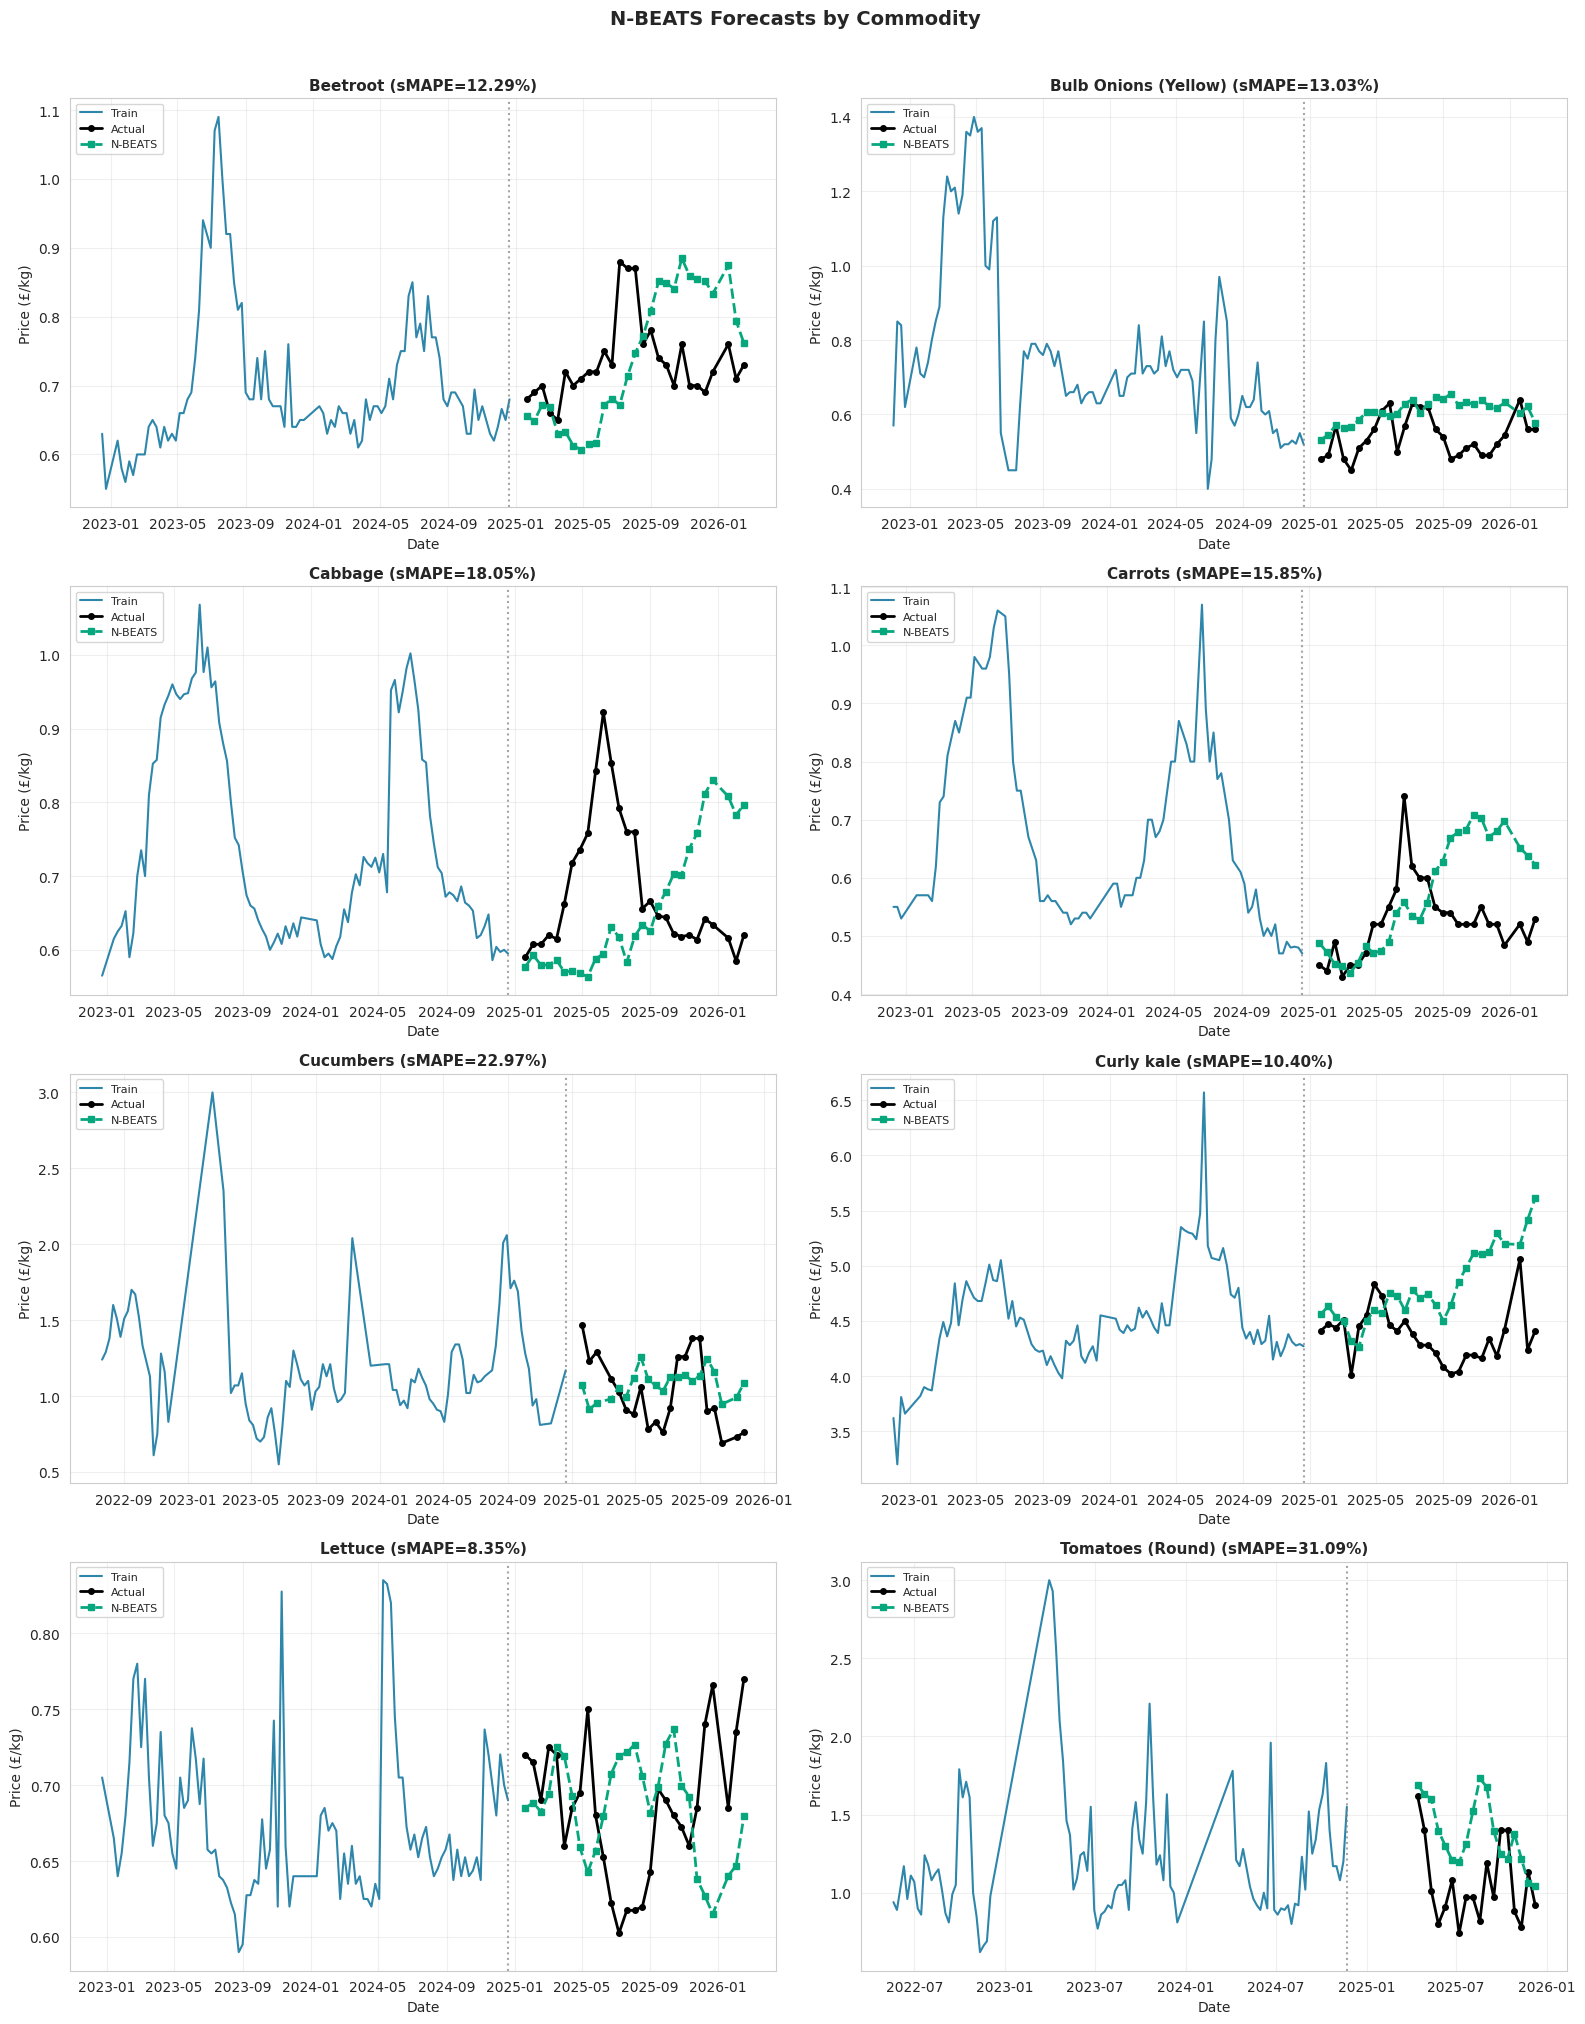

In [11]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for idx, comm in enumerate(commodities):
    ax = axes[idx]

    train_sub = nf_train[nf_train["unique_id"] == comm]
    test_sub = eval_df[eval_df["unique_id"] == comm]

    tail_n = min(100, len(train_sub))
    train_tail = train_sub.tail(tail_n)

    ax.plot(train_tail["ds"], train_tail["y"], label="Train", color="#2E86AB", linewidth=1.5)
    ax.plot(test_sub["ds"], test_sub["y"], label="Actual", color="black", linewidth=2, marker="o", markersize=4)
    ax.plot(test_sub["ds"], test_sub["NBEATS"], label="N-BEATS", color="#06A77D", linewidth=2, linestyle="--", marker="s", markersize=4)

    ax.axvline(x=train_sub["ds"].max(), color="gray", linestyle=":", linewidth=1.5, alpha=0.7)

    comm_metrics = per_commodity_df[per_commodity_df["Commodity"] == comm]
    if len(comm_metrics) > 0:
        smape_val = comm_metrics["sMAPE"].values[0]
        ax.set_title(f"{comm} (sMAPE={smape_val:.2%})", fontweight="bold", fontsize=11)
    else:
        ax.set_title(comm, fontweight="bold", fontsize=11)

    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (£/kg)")

plt.suptitle("N-BEATS Forecasts by Commodity", fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5 Summary

In [12]:
print("\n=== N-BEATS Summary ===\n")
print(metrics_df.to_string(index=False))
print(f"\nForecast horizon: {horizon} weeks")
print(f"Training time: {train_elapsed:.1f}s")
print(f"Forecast time: {forecast_elapsed:.1f}s")


=== N-BEATS Summary ===

Metric    Value
   MSE 0.079437
  RMSE 0.281846
   MAE 0.180700
  MAPE 0.169441
 sMAPE 0.155793

Forecast horizon: 28 weeks
Training time: 14.9s
Forecast time: 0.2s
